# Module 4: Coordinate Reference Systems


## Learning Objectives
At the end of this module, you should be able to:
- Define the key elements of coordinate reference systems (CRS)
- Define and reproject the coordinate reference system of a spatial dataset

## Coordinate reference systems

## Georeferencing

Majority of the information in the world can be traced to a specific location. This process of attaching a location to a piece of information is commonly referred to as `georeferencing`. There are various ways for georeferencing that represent data at different positional accuracy, such as place names (varying accuracy),  postal codes (accuracy at areal level), postal addresses (accuracy at door/mailbox level), or latitude and longitude coordinates (up to millimeter level accuracy).

Being able to position oneself on Earth has been an important task for humans for centuries. The most spatially accurate information about the location of a specific object can be obtained by using geodetic techniques. `Geodesy` is the science that focuses on accurately measuring and understanding different properties of the Earth, such as its shape, orientation in space and gravity. It also provides various fundamental methods that enable us to locate ourselves when using navigation services, or perform spatial analysis in a meaningful manner.

## Key elements of a Coordinate Reference System

Previously, we learned how geographic data can be represented on a computer as vector or raster data. This module focuses on one fundamental aspect of geographic data: `coordinate reference system` (also known as a Spatial Reference System). 

A coordinate reference system (`CRS`) is important because without CRS, geographic data is simply a collection of coordinates in an arbitrary space. A CRS tells GIS tools how the coordinates or geometries are related to places on Earth. In principle, every geographic dataset should have specific CRS-related information attached to it; otherwise it'll be difficult or impossible to use the data in GIS. This additional information is called `metadata`, because it provides important contextual information about the dataset, such as CRS or the timestamp when the data was created.

What kind of things are described with the Coordinate Reference System? A CRS typically describes the geographic data with three main components:

1. **Datum**: A datum specification consists of a model for Earth's size and shape, such as a reference ellipsoid or a geoid, which describes the average sea level surface of the Earth. One of the most commonly used datums is the World Geodetic System (WGS84). Datum also contains information about the origin of the coordinate system, i.e. the reference point at which the ellipsoid is tied to a known location on Earth. This is used as a reference for determining the location of other control points that have been precisely measured from the origin. Reference points are useful because they can also be used to check the accuracy of GNSS/GPS receivers. Finally, the datum includes the orientation parameters, which describe the orientation of the coordinate system with respect to the Earth's surface. They contain information about the tilt of the axis and the position of the origin relative to the Earth's surface. Watch this video: [ What are Geodetic Datums? ](https://www.youtube.com/watch?v=kXTHaMY3cVk) 

2. **Map projection**: The projection defines the mathematical transformation used to map the Earth's surface onto a two-dimensional plane. Each projection has its own strengths and weaknesses, and the choice of projection depends on the intended use of the map and the area to be mapped (see more details below).

3. **Additional Parameters**: These parameters define additional information required to fully define the CRS, such as the central meridian, standard parallel, and scale factor. These parameters may also include information about the origin and orientation of the coordinate system, and the conversion between the projected coordinates and the geographic coordinates.

It is important to note that a CRS can be either `geographic` (based on latitude and longitude) or `projected` (based on a Cartesian coordinate system). Geographic CRSs describe positions on the Earth's surface using latitude and longitude, while projected CRSs describe positions on a two-dimensional plane using a Cartesian coordinate system.

## Map projection - Representing curved surface in two dimensions

One core component of the coordinate reference system is the `map projection` which determines how we draw the geometries representing earth's curved surface on a two-dimensional plane. This process uses a mathematical method to map the coordinates of a location (latitude and longitude) onto a flat surface, i.e. on a map. As it happens, transforming data from 3D to 2D is not a straightforward process. When we use a map projection the output will always be distorted in some way or another. 

<img src="img/curved_surface_to_flat_plane.png" width="800">

_**Figure**. When representing the curved surface of the Earth in 2D space, the output will always be somehow distorted._

Watch this video: [Why all world maps are wrong](https://www.youtube.com/watch?v=kIID5FDi2JQ)

When using map projections, we always make approximations and hence lose something. There are no projections that would not distort anything or have the same scale throughout the map. Hence, a projection needs to be chosen according to the purpose of use, in order to preserve specific aspects of the map that are the most important to the user. These can be the shapes of objects, their surface areas, correct distances between locations, or the compass direction.

- If we want to preserve **angles** and ratios of distances, we speak of a conformal, or angle-preserving projections (such as Mercator projection). These kind of projections has historically been important for ship navigation. With conformal map projection, both the distances and surface areas are distorted, except at some special points of the map.
- If we want to preserve **area** measure, we speak of an equivalent or equal-area projection (such as Mollweide or Albers equal area). Here, the angles and shapes are distorted, with the exception of special points or lines. 
- If we want to preserve **distances**, we speak of an equidistant projection (such as Azimuthal equidistant). A projection can be equidistant only for a certain point (i.e. centered to specific location) or along certain lines, never everywhere.

Figure below illustrates 9 different map projections, where the latitude and longitude coordinates representing the land areas of the earth have been systematically transformed onto a flat surface. As you can see, there are numerous ways to represent the world in "flattened" state, and all the projections have their unique characteristics, strengths, and weaknesses. In other words, there is no perfect or "correct" projection, and one needs to choose a projection depending on the **purpose of the map**. Choosing an appropriate projection for your map is not always straightforward because it depends on what you actually want to represent with your map, and what is the **spatial scale of your data**.

<img src="img/projections.png" width="800">

_**Figure**. Different map projections that can be used to represent the geographic data on a two-dimensional plane._

## Storing Coordinate Reference System information 

The CRS information of a geographic dataset can be stored in various different ways. Some of the most common systems to store the CRS information are EPSG, PROJ, and OGC WKT. All of these basically serve the same purpose: they store the key characteristics of a given coordinate reference system in a standardized manner. Below is some basic information about the most commonly used systems to store CRS information:

- **EPSG registry** (Geodetic Parameter Dataset): This is a public registry maintained by the `European Petroleum Survey Group (EPSG)` that contains information on a wide range of coordinate reference systems, including geographic and projected CRSs, and datums. It is widely used in GIS software and is an open and freely accessible resource. EPSG codes are numbers that identify different CRS from each other. These numbers, such as 4326 for WGS84 coordinate system, are commonly used to determine a CRS for a specific dataset or when reprojecting the data, because these simple numbers are easy to remember and use. The number refers to an entry in the [EPSG Geodetic Parameter Dataset](http://www.epsg.org/), a collection of coordinate reference systems ranging from global to national, regional, and local scope.

- **PROJ system**: PROJ is another system and open source library for storing and transforming CRS information from one system to another. The CRS information is commonly stored as a "proj-strings", which includes information about the coordinate system as a plain text following specific naming conventions for the parameters. Typically these parameters provide information about the datum, ellipsoid, projection of the data, and units for the coordinates (e.g. meters). There can also be information about the Universal Transverse Mercator (UTM) zone if the data is using Cartesian coordinate system. In UTM, the data is presented on a plain and the world has been divided into 60 zones where each zone is 6-degrees of longitude in width. You can read more details about coordinate systems at the [PROJ website](https://proj.org/). As an example, PROJ4 text for the UTM Zone 16N coordinate system (EPSG:26916) commonly used for Michigan, is described with the following text: 

```
+proj=utm +zone=16 +datum=NAD83 +units=m +no_defs
```

- **OGC WKT**: Open Geospatial Consortium's (OGC) well-known text (WKT) representation of coordinate reference systems is also widely used format to store CRS information. This one is typically more lengthy as it aims to be human-readable and provide description about coordinate operations. The following shows how the UTM Zone 16N coordinate system (EPSG:26916) would be presented as OGC WKT:

    ```
    PROJCS["NAD83 / UTM zone 16N",
        GEOGCS["NAD83",
            DATUM["North_American_Datum_1983",
                SPHEROID["GRS80",6378137,298.257222101,
                    AUTHORITY["EPSG","7019"]],
                AUTHORITY["EPSG","6269"]],
            PRIMEM["Greenwich",0,
                AUTHORITY["EPSG","8901"]],
            UNIT["degree",0.0174532925199433,
                AUTHORITY["EPSG","9122"]],
            AUTHORITY["EPSG","4269"]],
        PROJECTION["Transverse_Mercator"],
        PARAMETER["latitude_of_origin",0],
        PARAMETER["central_meridian",-87],
        PARAMETER["scale_factor",0.9996],
        PARAMETER["false_easting",500000],
        PARAMETER["false_northing",0],
        UNIT["metre",1,
            AUTHORITY["EPSG","9001"]],
        AXIS["Easting",EAST],
        AXIS["Northing",NORTH],
        AUTHORITY["EPSG","26916"]]
    ```
All of these systems and formats are designed to ensure that CRS information can be stored, transmitted, and used consistently across different systems and applications, which is essential for accurate location-based data analysis and mapping.

## Working with map projections

Our main tool for managing coordinate reference systems is the [PROJ library](https://proj.org/) which can be used through the [pyproj](https://pyproj4.github.io/pyproj/stable/) Python library. `Pyproj` is bundled into geopandas and it can be used to access the CRS information of a given geographic dataset and also for reprojecting data from one coordinate system to another.

In the following, we will demonstrate how to work with coordinate reference systems in geopandas by using a country border dataset from Europe. We will reproject the dataset from the original WGS84 coordinate system into a Lambert Azimuthal Equal Area projection, a projection that European Union [recommends for Europe](http://mapref.org/LinkedDocuments/MapProjectionsForEurope-EUR-20120.pdf).

Let's start by reading the data from the `eu_countries.gpkg` file. When reading the data into GeoDataFrame with geopandas, the CRS information is automatically read from the datafile and stored into the `.crs` attribute:

In [1]:
import geopandas as gpd

# Read the file
data = gpd.read_file("data/eu_countries.gpkg")

# What is the type?
print(type(data.crs))

# Check the coordinate reference system information
data.crs

<class 'pyproj.crs.crs.CRS'>


<Geographic 2D CRS: EPSG:4326>
Name: WGS 84
Axis Info [ellipsoidal]:
- Lat[north]: Geodetic latitude (degree)
- Lon[east]: Geodetic longitude (degree)
Area of Use:
- name: World.
- bounds: (-180.0, -90.0, 180.0, 90.0)
Datum: World Geodetic System 1984 ensemble
- Ellipsoid: WGS 84
- Prime Meridian: Greenwich

What `geopandas` returns here is in fact a `CRS` object from the `pyproj` library. The EPSG code of our data is `4326` which refers to the WGS84 coordinate system. You will encounter this EPSG-code frequently in the geospatial world as it is perhaps the most commonly used coordinate reference system in the world. As we learned earlier, the EPSG number is an identification code that tells the coordinate system of a given dataset.

WGS84 is one of the most typical CRS to use with datasets that cover data from different parts of the world. However, WGS84 is not really a good coordinate system for representing European borders on a map because the areas get distorted, especially towards the North pole. Hence, it is a good idea to convert these geometries into [Lambert Azimuthal Equal Area projection](http://spatialreference.org/ref/epsg/etrs89-etrs-laea/) (EPSG:3035) which is a good option for creating maps with country-level data in Europe.

## Reprojecting a GeoDataFrame

Changing from one coordinate system to another is one of the most common tasks to do when working with geographic data. This process is commonly called `map reprojection`, `coordinate transformation`, or `geographic coordinate conversion`. When the data is reprojected, the coordinates described in one CRS transformed to another CRS by using specific geodetic equations. Knowing how to transform coordinates is important because different coordinate systems are used for different purposes, and it is often necessary to reproject some data to make them interoperable and comparable. 

For example, coordinates on the Earth's surface may be represented in geographic (latitude and longitude) or projected (Cartesian) coordinates, and the same location will have different coordinate values depending on the CRS used. It is important that the layers are in the same coordinate system when analyzing the spatial relationships between the layers. The transformation between the coordinate systems involves both translation and rotation, and requires knowledge of the shape and size of the Earth, as well as its orientation in space.

In geopandas, the `.to_crs()` method of a GeoDataFrame will perform coordinate transformations with given parameters. The method has two alternative parameters: 
1. `crs` which accepts CRS information from various formats, such as proj-strings or OGC WKT text; 
2. `epsg` that accepts the EPSG-code of a given coordinate system as a number. 

Both of these can be used to make the coordinate transformation and reproject the data into a desired CRS. Let's try it out and reproject our data into `EPSG:3035` using the `epsg` -parameter:

In [2]:
# Let's make a backup copy of our data
data_wgs84 = data.copy()

# Reproject the data
data = data.to_crs(epsg=3035)

# Check the new geometry values
data["geometry"].head()

0    MULTIPOLYGON (((4604288.477 2598607.470, 45914...
1    MULTIPOLYGON (((4059689.242 3049361.180, 40650...
2    MULTIPOLYGON (((5805367.757 2442801.252, 57739...
3    MULTIPOLYGON (((4833567.363 2848881.974, 48272...
4    MULTIPOLYGON (((6413299.362 1602181.345, 63782...
Name: geometry, dtype: geometry

In [3]:
# Check the new EPSG code
data.crs.to_epsg()

3035

Now we have successfully changed the CRS of our layer into a new one, i.e. to the planar `ETRS-LAEA` coordinate system (EPSG:3035). To understand the differences between the projections, we can explore the result visually by plotting the original and reprojected data side-to-side. 

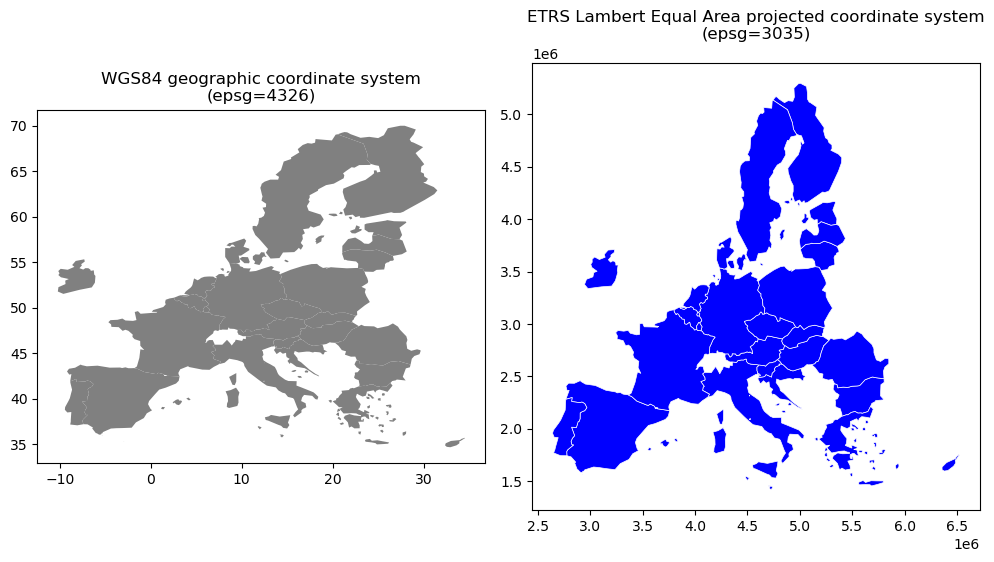

In [4]:
import matplotlib.pyplot as plt

# Make subplots that are next to each other
fig, (ax1, ax2) = plt.subplots(nrows=1, ncols=2, figsize=(10,10))

# Plot the data in WGS84 CRS
data_wgs84.plot(ax=ax1, facecolor="gray")

# Plot the one with ETRS-LAEA projection
data.plot(ax=ax2, facecolor="blue", edgecolor="white", lw=0.5)

# Add titles
ax1.set_title("WGS84 geographic coordinate system\n(epsg=4326)",fontsize=12)
ax2.set_title("ETRS Lambert Equal Area projected coordinate system\n(epsg=3035)", fontsize=12)

# Set aspect ratio as 1
ax1.set_aspect(aspect=1)
ax2.set_aspect(aspect=1)

# Remove empty white space around the plot
plt.tight_layout()

_**Figure**. Map of Europe plotted with two different coordinate reference systems (note that the coordinates are in different units)._

As we can see, the maps look quite different and the reprojected one looks significantly better especially in the North where the geometries are more realistic and not so stretched as in WGS84. Finally, let's save our projected layer into a Shapefile so that we can use it later. Note, even if the CRS information is stored with the output file (in this case into a `.prj` file associated with the Shapefile), it might be a good idea also to include CRS info in the filename which makes it easy to identify the CRS directly from the name of the file:

In [5]:
# Ouput filepath
outfp = "data/eu_countries_epsg3035.shp"

# Save to disk
data.to_file(outfp)